In [1]:
# --- Importe suas classes ---
# (Assumindo que estão no PYTHONPATH ou na mesma pasta)
from equation.option_pricing import BlackScholes
from optimize.option_princing import BlackScholeOptimizer
from method.nn import MLP, ResNet
from method.hnn import HybridCQN 
from method.qnn import QuantumNeuralNetwork, CorrelatorQuantumNeuralNetwork
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch as tc
import torch.nn as nn
import numpy as np
import json
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from utils.save import *



2026-01-29 22:19:39.230892: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-29 22:19:39.263178: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-29 22:19:39.985797: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# =============================================================================
# 0. CONFIGURAÇÃO
# =============================================================================

# Métrica principal para avaliar os modelos (use a desnormalizada)
MSE_COLUMN = 'mse_teste_desnormalizado'
LOSS_COLUMN = 'mean_last_100_loss' # ou 'mean_last_100_loss'

# Constantes de normalização (as mesmas usadas no treino)
S_max = 160.0
T = 1.0
V_max = 140.0

In [3]:
# =============================================================================
# 1. CARREGAR OS DADOS DO SUMÁRIO
# =============================================================================

all_dfs = []
summary = [SUMMARY_QUANTUM_PATH, SUMMARY_CQUANTUM_PATH]

for summar in summary:
    all_dfs.append(pd.read_csv(summar))


df_all = pd.concat(all_dfs, ignore_index=True)

valid_seeds = [1924, 1925, 1926, 1973, 2025, 2024, 2012, 1958, 1962, 1997]
list_layers = [1,3,5]

df_all = df_all[
    (df_all["seed"].isin(valid_seeds))  # filtragem pelas seeds
]

In [4]:
#df_hybrid = df_hybrid.drop_duplicates(subset=["hidden", "blocks", "seed"])
df_quantum = df_all[
    (df_all["model_type"] == "QNN") &
    (df_all["entangler"] == "strong") &
    (df_all['n_qubits'] == 7)
    ]

df_quantum = df_quantum[(df_all['n_layers']).isin(list_layers)]

df_quantum = df_quantum.drop_duplicates(subset=["seed", "n_qubits", "n_layers"])

/tmp/ipykernel_223001/3328804933.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_quantum = df_quantum[(df_all['n_layers']).isin(list_layers)]


In [5]:
#df_hybrid = df_hybrid.drop_duplicates(subset=["hidden", "blocks", "seed"])
df_qnn4 = df_all[
    (df_all["model_type"] == "QNN") &
    (df_all["entangler"] == "strong") &
    (df_all['n_qubits'] == 4)
    ]

df_qnn4 = df_qnn4[(df_all['n_layers']).isin(list_layers)]

df_qnn4 = df_qnn4.drop_duplicates(subset=["seed", "n_qubits", "n_layers"])

/tmp/ipykernel_223001/2185452707.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_qnn4 = df_qnn4[(df_all['n_layers']).isin(list_layers)]


In [6]:
df_cq2 = df_all[
    (df_all["model_type"] == "CQNN") &
    (df_all["entangler"] == "strong") &
    (df_all['k'] ==2) &
    (df_all['n_layers'] =='n_layers').isin([1,3,5])
    ].drop_duplicates()


df_cq2 = df_cq2.drop_duplicates(subset=["seed", "n_qubits", "n_layers", "k", "n_vertex"])

df_cq3 = df_all[
    (df_all["model_type"] == "CQNN") &
    (df_all["entangler"] == "strong") &
    (df_all['k'] == 3)
    ].drop_duplicates()


df_cq3 = df_cq3.drop_duplicates(subset=["seed", "n_qubits", "n_layers", "k", "n_vertex"])

In [7]:
sns.set_theme(style="whitegrid", context="talk")

df = df_quantum.copy()

# RMSE equivalente (se seu "mse" for realmente mean squared error)
df["rmse_teste_desnorm"] = np.sqrt(df["mse_teste_desnormalizado"])
df["rmse_teste_norm"]   = np.sqrt(df["mse_teste_normalizado"])


In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Threshold (ajuste para o seu caso)
TH = 1/140**2

# 2) Função para calcular taxa + num_params
def prepare_conv_df(df, label, TH=TH):
    d = df.copy()
    d["convergiu"] = d["mean_last_100_loss"] < TH
    out = (d.groupby(["n_qubits", "n_layers"], as_index=False)
             .agg(taxa=("convergiu", "mean"),
                  n=("convergiu", "count"),
                  num_params=("num_params", "first")))
    out["modelo"] = label
    return out

# 3) Seus dataframes (você já tem df_all e df_quantum)
# list_layers = [1,3,5]  # exemplo
list_layers = list_layers  # se já existe no seu notebook

# QNN (filtre igual você faz pros outros, se necessário)
conv_qnn = prepare_conv_df(df_quantum[df_quantum["n_layers"].isin(list_layers)], "QNN")

# CQNN k=2
df_cq2 = df_all[
    (df_all["model_type"] == "CQNN") &
    (df_all["entangler"] == "strong") &
    (df_all["k"] == 2) &
    (df_all["n_vertex"] == 7) &
    (df_all["n_layers"].isin(list_layers))
].drop_duplicates(subset=["seed", "n_qubits", "n_layers", "k", "n_vertex"])

conv_cq2 = prepare_conv_df(df_cq2, "$R-QNN^{(2)}$")

# CQNN k=3
df_cq3 = df_all[
    (df_all["model_type"] == "CQNN") &
    (df_all["entangler"] == "strong") &
    (df_all["k"] == 3) &
    (df_all["n_vertex"] == 7) &
    (df_all["n_layers"].isin(list_layers))
].drop_duplicates(subset=["seed", "n_qubits", "n_layers", "k", "n_vertex"])

conv_cq3 = prepare_conv_df(df_cq3, "$R-QNN^{(3)}$")

# 4) Junta tudo (isso é o que seu plot usa)
conv_plot = pd.concat([conv_qnn, conv_cq2, conv_cq3], ignore_index=True)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


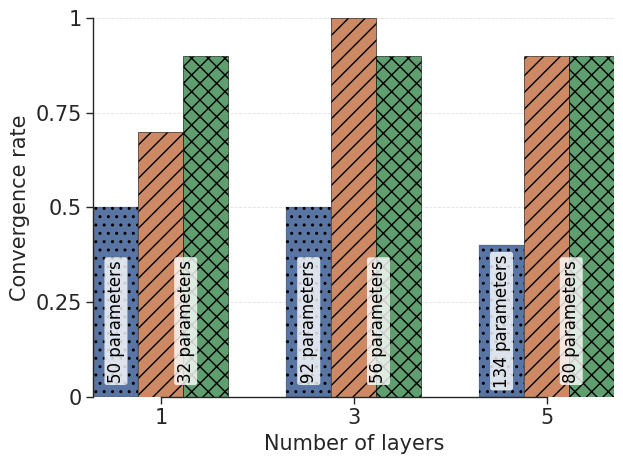

In [9]:
layers_order = sorted(conv_plot["n_layers"].unique())
models_order = ["QNN", "$R-QNN^{(2)}$", "$R-QNN^{(3)}$"]

sns.set_theme(style="ticks", context="paper", font_scale=1.25)

ax = sns.barplot(
    data=conv_plot,
    x="n_layers",
    y="taxa",
    hue="modelo",
    order=layers_order,
    hue_order=models_order,
    errorbar=None,
    width=0.7
)

ax.set_ylim(0, 1)
ax.set_xlabel("Number of layers", fontsize=15)
ax.set_ylabel("Convergence rate", fontsize=15)
ax.yaxis.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
ax.xaxis.grid(False)
sns.despine(trim=True)
ax.legend_.remove()

conv_plot2 = (
    conv_plot
    .assign(
        n_layers=pd.Categorical(conv_plot["n_layers"], categories=layers_order, ordered=True),
        modelo=pd.Categorical(conv_plot["modelo"], categories=models_order, ordered=True),
    )
    .sort_values(["modelo", "n_layers"])
)

# aplica hatch e anotações
for patch, (_, r) in zip(ax.patches, conv_plot2.iterrows()):
    patch.set_edgecolor("none")

    if r["modelo"] == "QNN":
        patch.set_hatch("..")
        patch.set_edgecolor("black")
        patch.set_linewidth(0.1)

    if pd.isna(r["num_params"]):
        continue

    x = patch.get_x() + patch.get_width()/2
    y = 0.2

    # 1) QNN: escreve na própria barra QNN
    if r["modelo"] == "QNN":
        ax.text(
            x, y,
            f"{int(r['num_params'])} parameters",
            ha="center", va="center",
            rotation=90,
            fontsize=12, color="black",
            #fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.15",
                facecolor="white",
                edgecolor="none",
                alpha=0.8
            )
        )

    # 2) R-QNN: escreve SÓ UMA VEZ (usa o (2) como referência)
    elif r["modelo"] == "$R-QNN^{(2)}$":
        patch.set_hatch("//")
        patch.set_edgecolor("black")
        patch.set_linewidth(0.4)

        dx = patch.get_width() * 0.55
        ax.text(
            x + dx, y,
            f"{int(r['num_params'])} parameters",
            ha="center", va="center",
            rotation=90,
            fontsize=12, color="black",
            #fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.15",
                facecolor="white",
                edgecolor="none",
                alpha=0.8
            )
        )

    # 3) R-QNN^{(3)}: só hatch
    elif r["modelo"] == "$R-QNN^{(3)}$":
        patch.set_hatch("xx")
        patch.set_edgecolor("black")
        patch.set_linewidth(0.4)

ax.tick_params(axis="both", labelsize=15)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0", "0.25", "0.5", "0.75", "1"])

ax.margins(x=0)

plt.tight_layout()
plt.savefig("./paper_reduced/plot/convergence_4qubits.eps", dpi=300)
plt.show()


/tmp/ipykernel_223001/1529833834.py:147: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


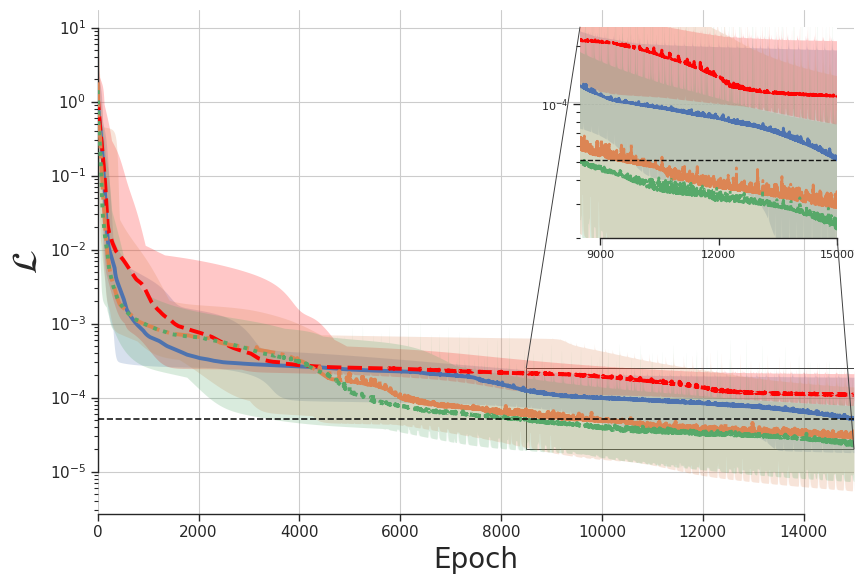

In [10]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# ======================================================
# CONFIG
# ======================================================
BASE = "./experimentos_pinn/"
QCSV = BASE + "sumario_quantico.csv"
CCSV = BASE + "sumario_cquantico.csv"

LOSS_KEY = "Total"
LOSS_COL = "mean_last_100_loss"

SEEDS  = [1924, 1925, 1926, 1973, 2025, 2024, 2012, 1958, 1962, 1997]
LAYERS = [1, 3, 5]

TH = 1/140**2

# ZOOM (ajuste aqui)
X1, X2 = 8500, 15000
Y1, Y2 = 2e-5, 2.5e-4

# SOMBRAS mais fortes
SHADE_ALPHA_MAIN = 0.22
SHADE_ALPHA_INSET = 0.22

# ======================================================
# STYLE
# ======================================================
sns.set_theme(style="ticks", context="paper", font_scale=1.25)

base = sns.color_palette("deep", 3)
color_map = {
    "QNN$_{7}$": base[0],
    "QNN$_{4}$": "red",
    "R-QNN$^{(2)}_{4}$": base[1],
    "R-QNN$^{(3)}_{4}$": base[2],
}
ls_map = {
    "QNN$_{7}$": "-",
    "QNN$_{4}$": "--",
    "R-QNN$^{(2)}_{4}$": "-.",
    "R-QNN$^{(3)}_{4}$": ":",
}
order_models = ["QNN$_{7}$", "QNN$_{4}$", "R-QNN$^{(2)}_{4}$", "R-QNN$^{(3)}_{4}$"]

# ======================================================
# LOAD CSVs
# ======================================================
df = pd.concat([pd.read_csv(QCSV), pd.read_csv(CCSV)], ignore_index=True)

df["loss_history_path"] = (
    df["loss_history_path"].astype(str)
      .str.replace("^experimentos_pinn/", "", regex=True)
)

df = df[
    (df["entangler"] == "strong") &
    (df["seed"].isin(SEEDS)) &
    (df["n_layers"].isin(LAYERS))
].copy()

models = {
    "QNN$_{7}$": df[(df["model_type"] == "QNN")  & (df["n_qubits"] == 7)],
    "QNN$_{4}$": df[(df["model_type"] == "QNN")  & (df["n_qubits"] == 4)],
    "R-QNN$^{(2)}_{4}$": df[(df["model_type"] == "CQNN") & (df["k"] == 2) & (df["n_vertex"] == 7)],
    "R-QNN$^{(3)}_{4}$": df[(df["model_type"] == "CQNN") & (df["k"] == 3) & (df["n_vertex"] == 7)],
}

# ======================================================
# PLOT (1 figura + inset menor + sombras destacadas)
# ======================================================
plt.figure(figsize=(8.8, 6))
main = plt.gca()

# inset MENOR (reduzi width/height)
ins = inset_axes(main, width="34%", height="42%", loc="upper right", borderpad=1.1)

for label in order_models:
    d = models[label].dropna(subset=["loss_history_path", LOSS_COL]).drop_duplicates(["seed", "n_layers"])
    if len(d) == 0:
        continue

    curves = []
    for p in d["loss_history_path"]:
        full = os.path.join(BASE, p)
        if os.path.exists(full):
            with open(full, "r") as f:
                curves.append(np.array(json.load(f)[LOSS_KEY], dtype=float))

    if len(curves) == 0:
        continue

    Lmin = min(len(c) for c in curves)
    M = np.stack([c[:Lmin] for c in curves], axis=0)

    x   = np.arange(Lmin)
    med = np.median(M, axis=0)
    mn  = np.min(M, axis=0)
    mx  = np.max(M, axis=0)

    # MAIN
    plt.sca(main)
    plt.plot(x, med, lw=2.8, ls=ls_map[label], color=color_map[label], alpha=0.98, zorder=3)
    plt.fill_between(x, mn, mx, color=color_map[label], alpha=SHADE_ALPHA_MAIN, linewidth=0, zorder=2)

    # INSET
    plt.sca(ins)
    plt.plot(x, med, lw=2.0, ls=ls_map[label], color=color_map[label], alpha=0.98, zorder=3)
    plt.fill_between(x, mn, mx, color=color_map[label], alpha=SHADE_ALPHA_INSET, linewidth=0, zorder=2)

# threshold
plt.sca(main)
plt.hlines(TH, 0, 15000, lw=1.2, ls="--", color="black", alpha=0.9, zorder=4)

plt.sca(ins)
plt.hlines(TH, X1, X2, lw=1.0, ls="--", color="black", alpha=0.9, zorder=4)

# MAIN estética
plt.sca(main)
plt.xlim(0, 15000)
plt.yscale("log")
plt.xlabel("Epoch", fontsize=20)
plt.ylabel(r"$\mathcal{L}$", fontsize=25)
plt.grid(True)
sns.despine(trim=True, ax=main)

# INSET estética (zoom)
plt.sca(ins)
plt.xlim(X1, X2)
plt.yscale("log")
plt.ylim(Y1, Y2)
plt.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
plt.tick_params(labelsize=8)
plt.xticks([9_000, 12_000, 15_000])
sns.despine(trim=True, ax=ins)

# marca região (linhas um pouco mais leves)
mark_inset(main, ins, loc1=2, loc2=4, fc="none", ec="0.25", lw=0.7)

plt.tight_layout()
plt.savefig('./paper_reduced/plot/loss_history.png', dpi=300)
plt.show()


/tmp/ipykernel_223001/1034991591.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_223001/1034991591.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_223001/1034991591.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


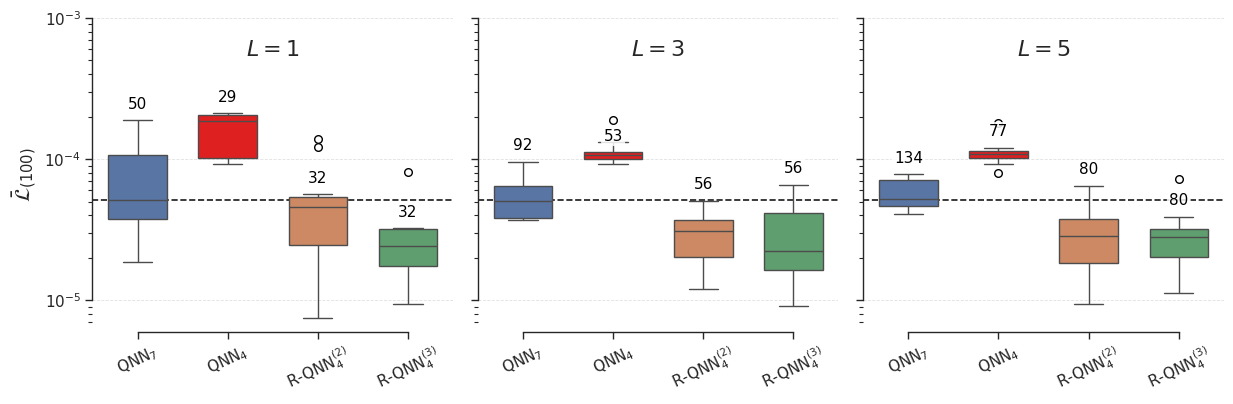

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks", context="paper", font_scale=1.25)

# ======================================================
# Config (usa df, LOSS_COL, TH, etc. já definidos)
# ======================================================
d_q7 = df[(df["model_type"]=="QNN")  & (df["n_qubits"]==7)].copy()
d_q7["modelo"] = "QNN$_7$"

d_q4 = df[(df["model_type"]=="QNN")  & (df["n_qubits"]==4)].copy()
d_q4["modelo"] = "QNN$_4$"

d_r2 = df[(df["model_type"]=="CQNN") & (df["k"]==2) & (df["n_vertex"]==7)].copy()
d_r2["modelo"] = r"R-QNN$^{(2)}_4$"

d_r3 = df[(df["model_type"]=="CQNN") & (df["k"]==3) & (df["n_vertex"]==7)].copy()
d_r3["modelo"] = r"R-QNN$^{(3)}_4$"

box_df = pd.concat([d_q7, d_q4, d_r2, d_r3], ignore_index=True)
box_df = box_df.drop_duplicates(subset=["seed", "n_layers", "modelo"])
box_df = box_df.dropna(subset=[LOSS_COL])

models_order = ["QNN$_7$", "QNN$_4$", r"R-QNN$^{(2)}_4$", r"R-QNN$^{(3)}_4$"]
layers_order = sorted(box_df["n_layers"].unique())

base = sns.color_palette("deep", 3)
palette = {
    "QNN$_7$": base[0],
    "QNN$_4$": "red",
    r"R-QNN$^{(2)}_4$": base[1],
    r"R-QNN$^{(3)}_4$": base[2],
}

# ======================================================
# EIXO Y PADRÃO (mesmo range e ticks)
# ======================================================
ymin = box_df[LOSS_COL].min() * 0.8
ymax = box_df[LOSS_COL].max() * 1.2

yticks = [1e-5, 1e-4, 1e-3]
yticklabs = [r"$10^{-5}$", r"$10^{-4}$", r"$10^{-3}$"]

# ======================================================
# PLOT
# ======================================================
fig, axes = plt.subplots(1, len(layers_order), figsize=(12.5, 4.2), sharey=True)
if len(layers_order) == 1:
    axes = [axes]

for ax, L in zip(axes, layers_order):
    dL = box_df[box_df["n_layers"] == L]

    # --- para escrever num_params acima de cada box:
    # pega "um" num_params por modelo (assume constante por modelo e layer)
    params_map = (
        dL.groupby("modelo")["num_params"]
          .first()
          .reindex(models_order)
          .to_dict()
    )

    sns.boxplot(
        data=dL,
        x="modelo",
        y=LOSS_COL,
        order=models_order,
        palette=palette,
        width=0.65,
        showfliers=True,
        linewidth=1.0,
        # OUTLIERS mais destacados:
        flierprops=dict(
            marker="o",
            markersize=5.5,
            markerfacecolor="white",
            markeredgecolor="black",
            markeredgewidth=1.0,
            alpha=1.0
        ),
        ax=ax
    )

    # eixo y padrão
    ax.set_yscale("log")
    ax.set_ylim(ymin, ymax)
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticklabs)

    # linha de threshold
    ax.axhline(
        TH,
        color="black",
        linestyle="--",
        linewidth=1.2,
        alpha=0.9,
        zorder=0
    )

    # texto "L = ..." centralizado e maior
    ax.text(
        0.50, 0.93,
        rf"$L={L}$",
        transform=ax.transAxes,
        ha="center", va="top",
        fontsize=16
    )

    # grid e estilo padrão
    ax.set_xlabel("")
    ax.yaxis.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
    ax.xaxis.grid(False)
    sns.despine(trim=True, ax=ax)
    ax.tick_params(axis="x", labelsize=11, rotation=25)

    # --------------------------------------------------
    # escreve num_params acima da "barrinha" (whisker top)
    # sem cair em cima dos outliers: usa ymax do whisker
    # --------------------------------------------------
    # encontra, para cada categoria, o valor máximo NÃO-outlier via IQR:
    # upper_whisker = min(max, q3 + 1.5*IQR)
    for i, m in enumerate(models_order):
        vals = dL.loc[dL["modelo"] == m, LOSS_COL].to_numpy()
        if len(vals) == 0:
            continue

        q1 = np.quantile(vals, 0.25)
        q3 = np.quantile(vals, 0.75)
        iqr = q3 - q1
        upper_whisker = np.max(vals[vals <= (q3 + 1.5 * iqr)]) if np.any(vals <= (q3 + 1.5 * iqr)) else np.max(vals)

        # coloca um pouco acima do whisker
        y_text = upper_whisker * 1.15

        p = params_map.get(m, np.nan)
        if pd.isna(p):
            continue

        ax.text(
            i, y_text,
            f"{int(p)}",
            ha="center", va="bottom",
            fontsize=11,
            color="black",
            bbox=dict(
                boxstyle="round,pad=0.15",
                facecolor="white",
                edgecolor="none",
                alpha=0.85
            )
        )

axes[0].set_ylabel(r"$\bar{\mathcal{L}}_{(100)}$", fontsize=15)
for ax in axes[1:]:
    ax.set_ylabel("")

plt.tight_layout()
#plt.savefig("./paper_reduced/plot/boxplot_mean_last_100_by_layers_threshold_outliers.png", dpi=300)
plt.show()


/tmp/ipykernel_223001/3170277713.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_223001/3170277713.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_223001/3170277713.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


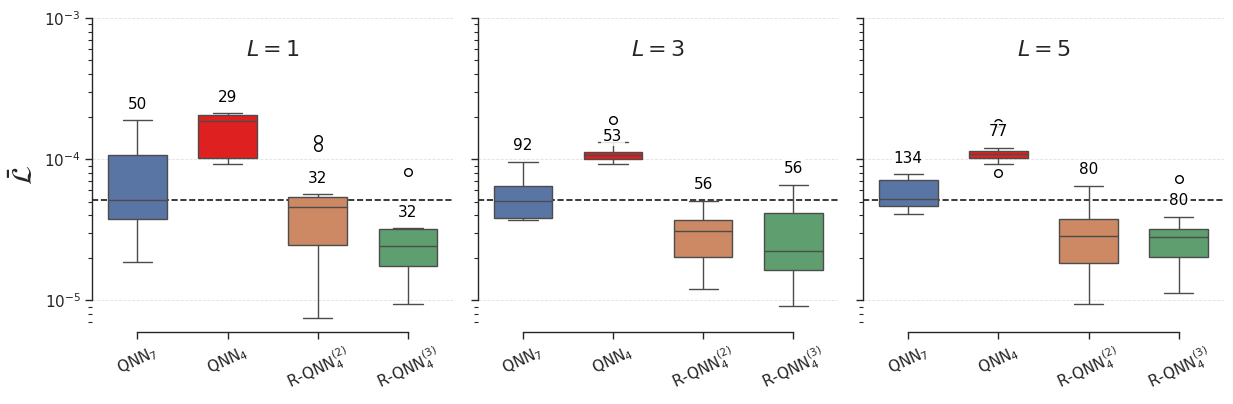

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks", context="paper", font_scale=1.25)

# ======================================================
# Config (usa df, LOSS_COL, TH, etc. já definidos)
# ======================================================
d_q7 = df[(df["model_type"]=="QNN")  & (df["n_qubits"]==7)].copy()
d_q7["modelo"] = "QNN$_7$"

d_q4 = df[(df["model_type"]=="QNN")  & (df["n_qubits"]==4)].copy()
d_q4["modelo"] = "QNN$_4$"

d_r2 = df[(df["model_type"]=="CQNN") & (df["k"]==2) & (df["n_vertex"]==7)].copy()
d_r2["modelo"] = r"R-QNN$^{(2)}_4$"

d_r3 = df[(df["model_type"]=="CQNN") & (df["k"]==3) & (df["n_vertex"]==7)].copy()
d_r3["modelo"] = r"R-QNN$^{(3)}_4$"

box_df = pd.concat([d_q7, d_q4, d_r2, d_r3], ignore_index=True)
box_df = box_df.drop_duplicates(subset=["seed", "n_layers", "modelo"])
box_df = box_df.dropna(subset=[LOSS_COL])

models_order = ["QNN$_7$", "QNN$_4$", r"R-QNN$^{(2)}_4$", r"R-QNN$^{(3)}_4$"]
layers_order = sorted(box_df["n_layers"].unique())

base = sns.color_palette("deep", 3)
palette = {
    "QNN$_7$": base[0],
    "QNN$_4$": "red",
    r"R-QNN$^{(2)}_4$": base[1],
    r"R-QNN$^{(3)}_4$": base[2],
}

# ======================================================
# EIXO Y PADRÃO (mesmo range e ticks)
# ======================================================
ymin = box_df[LOSS_COL].min() * 0.8
ymax = box_df[LOSS_COL].max() * 1.2

yticks = [1e-5, 1e-4, 1e-3]
yticklabs = [r"$10^{-5}$", r"$10^{-4}$", r"$10^{-3}$"]

# ======================================================
# PLOT
# ======================================================
fig, axes = plt.subplots(1, len(layers_order), figsize=(12.5, 4.2), sharey=True)
if len(layers_order) == 1:
    axes = [axes]

for ax, L in zip(axes, layers_order):
    dL = box_df[box_df["n_layers"] == L]

    # --- para escrever num_params acima de cada box:
    # pega "um" num_params por modelo (assume constante por modelo e layer)
    params_map = (
        dL.groupby("modelo")["num_params"]
          .first()
          .reindex(models_order)
          .to_dict()
    )

    sns.boxplot(
        data=dL,
        x="modelo",
        y=LOSS_COL,
        order=models_order,
        palette=palette,
        width=0.65,
        showfliers=True,
        linewidth=1.0,
        # OUTLIERS mais destacados:
        flierprops=dict(
            marker="o",
            markersize=5.5,
            markerfacecolor="white",
            markeredgecolor="black",
            markeredgewidth=1.0,
            alpha=1.0
        ),
        ax=ax
    )

    # eixo y padrão
    ax.set_yscale("log")
    ax.set_ylim(ymin, ymax)
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticklabs)
    ax.yaxis.get_offset_text().set_visible(False)

    # linha de threshold
    ax.axhline(
        TH,
        color="black",
        linestyle="--",
        linewidth=1.2,
        alpha=0.9,
        zorder=0
    )

    # texto "L = ..." centralizado e maior
    ax.text(
        0.50, 0.93,
        rf"$L={L}$",
        transform=ax.transAxes,
        ha="center", va="top",
        fontsize=16
    )

    # grid e estilo padrão
    ax.set_xlabel("")
    ax.yaxis.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
    ax.xaxis.grid(False)
    sns.despine(trim=True, ax=ax)
    ax.tick_params(axis="x", labelsize=11, rotation=25)

    # --------------------------------------------------
    # escreve num_params acima da "barrinha" (whisker top)
    # sem cair em cima dos outliers: usa ymax do whisker
    # --------------------------------------------------
    # encontra, para cada categoria, o valor máximo NÃO-outlier via IQR:
    # upper_whisker = min(max, q3 + 1.5*IQR)
    for i, m in enumerate(models_order):
        vals = dL.loc[dL["modelo"] == m, LOSS_COL].to_numpy()
        if len(vals) == 0:
            continue

        q1 = np.quantile(vals, 0.25)
        q3 = np.quantile(vals, 0.75)
        iqr = q3 - q1
        upper_whisker = np.max(vals[vals <= (q3 + 1.5 * iqr)]) if np.any(vals <= (q3 + 1.5 * iqr)) else np.max(vals)

        # coloca um pouco acima do whisker
        y_text = upper_whisker * 1.15

        p = params_map.get(m, np.nan)
        if pd.isna(p):
            continue

        ax.text(
            i, y_text,
            f"{int(p)}",
            ha="center", va="bottom",
            fontsize=11,
            color="black",
            bbox=dict(
                boxstyle="round,pad=0.15",
                facecolor="white",
                edgecolor="none",
                alpha=0.85
            )
        )

axes[0].set_ylabel(r"$\bar{\mathcal{L}}$", fontsize=20)
for ax in axes[1:]:
    ax.set_ylabel("")

plt.tight_layout()
plt.savefig("./paper_reduced/plot/boxplot.png", dpi=300)
plt.show()


In [13]:
def make_grid_BS(bs, Ns=201, Nt=201, option_type="call", include_endpoints=True):
    """
    bs: instância da classe BlackScholes (do teu código)
    Ns, Nt: nº de pontos em S e t
    option_type: 'call' ou 'put'
    include_endpoints: se True, inclui S=0,S=Smax e t=0,t=T
    """
    if include_endpoints:
        S_lin = np.linspace(0.0, bs.S_max, Ns)
        t_lin = np.linspace(0.0, bs.T, Nt)
    else:
        # evita exatamente 0 e T (às vezes útil p/ evitar tau=0 em PINN)
        eps = bs.eps
        S_lin = np.linspace(eps, bs.S_max - eps, Ns)
        t_lin = np.linspace(eps, bs.T - eps, Nt)

    S_mesh, t_mesh = np.meshgrid(S_lin, t_lin, indexing="ij")  # (Ns, Nt)

    # Flatten no mesmo estilo que você usa (N,1)
    S_grid = S_mesh.reshape(-1, 1)
    t_grid = t_mesh.reshape(-1, 1)

    V_true = bs.V(S_grid, t_grid, option_type=option_type)

    return {
        "grid": (S_grid, t_grid, V_true),
        "meta": {"Ns": Ns, "Nt": Nt, "shape_mesh": (Ns, Nt)}
    }

In [ ]:
# ============================================================
# FULL CODE (single cell) — fixed cache schema
# - If cache CSV exists but misses required columns, it rebuilds it.
# - Everything uses 1000×1000 for MSE mesh and 3D surfaces (picks).
# - Delivers: (1) LOSS×MSE log-log with quadrant texts (per-model)
#            (2) 3D panels (median & best) V(S,t) colored by squared error, wireframe grid
#            (3) 2D curves t=0,0.5,1 (median pick), shared y + inset zoom with shared inset y-range
# - Saves caches:
#     cache_mse_mesh_1000x1000.csv
#     cache_curves_median_t0_t05_t1.csv
# ============================================================

import os
import numpy as np
import pandas as pd
import torch as tc
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib import rcParams
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# --- Your project imports ---
from equation.option_pricing import BlackScholes
from method.hnn import HybridCQN
from method.qnn import QuantumNeuralNetwork, CorrelatorQuantumNeuralNetwork

# ============================================================
# CONFIG
# ============================================================
RESULTS_DIR = "experimentos_pinn"
QCSV = os.path.join(RESULTS_DIR, "sumario_quantico.csv")
CCSV = os.path.join(RESULTS_DIR, "sumario_cquantico.csv")

device_eval  = "cpu"   # "cuda" if you want
option_type  = "call"

S_max = 160.0
T     = 1.0
V_max = 140.0

SEEDS  = [1924, 1925, 1926, 1973, 2025, 2024, 2012, 1958, 1962, 1997]
LAYERS = [1, 3, 5]

MSE_THR  = 1.0
LOSS_THR = 1.0 / (V_max**2)

GRID_NS = 1000
GRID_NT = 1000
PRED_CHUNK = 120_000

SURF_DS = 6

N_LINE = 1800
t_list = [0.0, 0.5, 1.0]
XIN1, XIN2 = 20.0, 50.0

CACHE_MSECSV  = os.path.join(RESULTS_DIR, "cache_mse_mesh_1000x1000.csv")
CACHE_CURVCSV = os.path.join(RESULTS_DIR, "cache_curves_median_t0_t05_t1.csv")

# ============================================================
# STYLE
# ============================================================
sns.set_theme(style="ticks", context="paper", font_scale=1.25)

base = sns.color_palette("deep", 3)
color_map = {
    "QNN$_7$": base[0],
    "QNN$_4$": "red",
    r"R-QNN$^{(2)}_4$": base[1],
    r"R-QNN$^{(3)}_4$": base[2],
}
order_models = list(color_map.keys())
cols_order   = ["Analytic"] + order_models

marker_model = {
    "QNN$_7$": "o",
    "QNN$_4$": "s",
    r"R-QNN$^{(2)}_4$": "^",
    r"R-QNN$^{(3)}_4$": "D",
}
median_marker = "*"

ls_map = {
    "Analytic": "-",
    "QNN$_7$": "-",
    "QNN$_4$": "--",
    r"R-QNN$^{(2)}_4$": "-.",
    r"R-QNN$^{(3)}_4$": ":",
}

# ============================================================
# NORMALIZATION (training convention)
# ============================================================
def norm_in(S, t):
    return S / S_max, t / T

def denorm_out(V_norm):
    return V_norm * V_max

# ============================================================
# PATH FIXER
# ============================================================
def resolve_artifact_path(p):
    if p is None or (isinstance(p, float) and np.isnan(p)):
        return p
    p = str(p)
    if os.path.isabs(p) and os.path.exists(p):
        return p
    if os.path.exists(p):
        return p
    p2 = os.path.join(RESULTS_DIR, p)
    if os.path.exists(p2):
        return p2
    base = os.path.basename(p)
    for root, _, files in os.walk(RESULTS_DIR):
        if base in files:
            return os.path.join(root, base)
    return p2

# ============================================================
# MODEL FACTORY (must match training)
# ============================================================
def build_model_from_row(row, device="cpu"):
    model_type = row["model_type"]

    if model_type == "QNN":
        qnn = QuantumNeuralNetwork(
            n_qubits=int(row["n_qubits"]),
            n_layers=int(row["n_layers"]),
            device=device,
            entangler=row.get("entangler", "strong"),
        )
        model = HybridCQN(classical_pre=None, qnn_block=qnn, device=device, classical_post=None)

    elif model_type in ["CQNN", "CQNN_nonlinear"]:
        qnn = CorrelatorQuantumNeuralNetwork(
            n_qubits=int(row["n_qubits"]),
            n_layers=int(row["n_layers"]),
            k=int(row["k"]),
            n_vertex=int(row["n_vertex"]),
            nonlinear=(model_type == "CQNN_nonlinear"),
            device=device,
            entangler=row.get("entangler", "strong"),
        )
        model = HybridCQN(classical_pre=None, qnn_block=qnn, device=device, classical_post=None)

    else:
        raise ValueError(f"Unsupported model_type in this script: {model_type}")

    return model

def load_model_from_row(row, device="cpu"):
    model = build_model_from_row(row, device=device).to(device)

    model_path = resolve_artifact_path(row["model_path"])
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model not found: {model_path} (row['model_path']={row['model_path']})")

    state = tc.load(model_path, map_location=device)
    model.load_state_dict(state, strict=True)
    model.eval()
    return model

@tc.no_grad()
def predict_on_mesh(model, S_mesh, t_mesh, device="cpu", chunk=PRED_CHUNK):
    Ns, Nt = S_mesh.shape
    Sg = S_mesh.reshape(-1, 1)
    tg = t_mesh.reshape(-1, 1)

    S_n, t_n = norm_in(Sg, tg)
    X = np.concatenate([S_n, t_n], axis=1).astype(np.float32)
    X_t = tc.from_numpy(X).to(device)

    outs = []
    for i in range(0, X_t.shape[0], chunk):
        outs.append(model(X_t[i:i+chunk]).detach().cpu().numpy())

    V_pred_norm = np.vstack(outs).reshape(Ns, Nt)
    return denorm_out(V_pred_norm)

def mse_from_mesh(V_pred, V_true):
    return float(np.mean((V_pred - V_true)**2))

# ============================================================
# LOAD summary CSVs -> df
# ============================================================
df = pd.concat([pd.read_csv(QCSV), pd.read_csv(CCSV)], ignore_index=True)

df = df[
    (df["entangler"] == "strong") &
    (df["seed"].isin(SEEDS)) &
    (df["n_layers"].isin(LAYERS))
].copy()

df["model_path_abs"] = df["model_path"].apply(resolve_artifact_path)

# Split into four groups
groups = {
    "QNN$_7$": df[(df["model_type"]=="QNN")  & (df["n_qubits"]==7)].copy(),
    "QNN$_4$": df[(df["model_type"]=="QNN")  & (df["n_qubits"]==4)].copy(),
    r"R-QNN$^{(2)}_4$": df[(df["model_type"]=="CQNN") & (df["k"]==2) & (df["n_vertex"]==7)].copy(),
    r"R-QNN$^{(3)}_4$": df[(df["model_type"]=="CQNN") & (df["k"]==3) & (df["n_vertex"]==7)].copy(),
}

for k in groups:
    groups[k] = groups[k].dropna(subset=["model_path_abs"]).copy()
    cols = [c for c in ["seed","n_layers","k","n_vertex","n_qubits"] if c in groups[k].columns]
    if cols:
        groups[k] = groups[k].drop_duplicates(subset=cols, keep="first")

# Ensure loss column exists: if not, fallback to another name if present
LOSS_COL_CANDIDATES = ["mean_last_100_loss", "final_total_loss"]
def ensure_loss_col(d):
    for c in LOSS_COL_CANDIDATES:
        if c in d.columns:
            return c
    raise KeyError("No loss column found. Expected one of: mean_last_100_loss / final_total_loss")

loss_col = ensure_loss_col(df)

# ============================================================
# ANALYTIC GRID (1000×1000)
# ============================================================
bs = BlackScholes(S_max=S_max, T=T, K=40, r=0.05, sigma=0.2, eps=1e-10)

S_lin = np.linspace(0.0, S_max, GRID_NS)
t_lin = np.linspace(0.0, T, GRID_NT)
S_mesh, t_mesh = np.meshgrid(S_lin, t_lin, indexing="ij")  # (Ns,Nt)

V_true = bs.V(S_mesh.reshape(-1,1), t_mesh.reshape(-1,1), option_type=option_type).reshape(GRID_NS, GRID_NT)

# ============================================================
# (A) BUILD OR LOAD cache_mse_mesh_1000x1000.csv (schema-checked)
# ============================================================
REQUIRED_CACHE_COLS = {"modelo","seed","n_layers","mse_mesh","model_path",loss_col}

def cache_is_valid(path):
    if not os.path.exists(path):
        return False
    try:
        tmp = pd.read_csv(path, nrows=5)
        return REQUIRED_CACHE_COLS.issubset(set(tmp.columns))
    except Exception:
        return False

if cache_is_valid(CACHE_MSECSV):
    plot_df = pd.read_csv(CACHE_MSECSV)
else:
    rows = []
    for label in order_models:
        d = groups[label].dropna(subset=[loss_col]).copy()

        for _, row in tqdm(d.iterrows(), total=len(d), desc=f"MSE(mesh 1000x1000) {label}"):
            r = row.to_dict()
            r["model_path"] = r["model_path_abs"]
            try:
                model = load_model_from_row(r, device=device_eval)
                Vp = predict_on_mesh(model, S_mesh, t_mesh, device=device_eval)
                mse = mse_from_mesh(Vp, V_true)
            except Exception:
                mse = np.nan

            rows.append({
                "modelo": label,
                "seed": int(row["seed"]),
                "n_layers": int(row["n_layers"]),
                loss_col: float(row[loss_col]),
                "mse_mesh": float(mse) if np.isfinite(mse) else np.nan,
                "model_path": r["model_path"],
                "model_type": row.get("model_type", None),
                "n_qubits": row.get("n_qubits", None),
                "k": row.get("k", None),
                "n_vertex": row.get("n_vertex", None),
                "entangler": row.get("entangler", None),
            })

    plot_df = pd.DataFrame(rows).dropna(subset=["mse_mesh", loss_col]).copy()
    plot_df.to_csv(CACHE_MSECSV, index=False)

# ============================================================
# Picks per model:
# - median-by-loss (closest to median loss)
# - best-by-mesh-MSE (minimum mse_mesh)
# ============================================================
def pick_median_by_loss(df_model):
    loss = df_model[loss_col].to_numpy()
    med = np.median(loss)
    idx = int(np.argmin(np.abs(loss - med)))
    return df_model.iloc[idx]

def pick_best_by_mse(df_model):
    return df_model.sort_values("mse_mesh", ascending=True).iloc[0]

picks_median = {m: pick_median_by_loss(plot_df[plot_df["modelo"]==m].copy()) for m in order_models}
picks_best   = {m: pick_best_by_mse(plot_df[plot_df["modelo"]==m].copy()) for m in order_models}

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

'\n# ============================================================\n# (2) 3D surfaces: median picks and best picks\n#     - (a)-(e) labels, no global title\n#     - surface: V(S,t) colored by squared error\n#     - analytic: different colormap\n#     - add wireframe grid\n#     - colorbar label only "MSE"\n# ============================================================\ndef row_to_modeldict(row):\n    # plot_df cache might not include full hyperparams; recover from df if needed\n    # easiest: search original df by model_path_abs\n    mp = row["model_path"]\n    # find in df\n    hit = df[df["model_path_abs"] == mp]\n    if len(hit) == 0:\n        # fallback: try basename match\n        base = os.path.basename(mp)\n        hit = df[df["model_path_abs"].astype(str).str.endswith(base)]\n    if len(hit) == 0:\n        # last resort: use what exists in row (may break for CQNN)\n        return row.to_dict()\n\n    h = hit.iloc[0].to_dict()\n    h["model_path"] = mp\n    return h\n\ndef comput

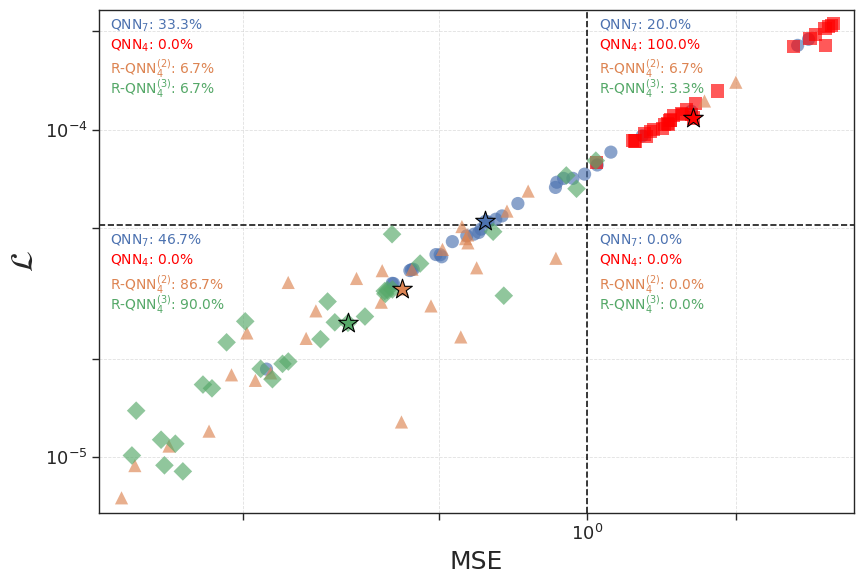

In [17]:
# ============================================================
# (1) LOSS×MSE — log-log, ticks limpos, textos bem posicionados
# ============================================================
fig, ax = plt.subplots(figsize=(8.8, 6))

# --- scatters ---
for label in order_models:
    d = plot_df[plot_df["modelo"] == label]

    ax.scatter(
        d["mse_mesh"], d[loss_col],
        s=90,
        marker=marker_model[label],
        color=color_map[label],
        alpha=0.65,            # <-- menos translúcido
        edgecolor="none",
        zorder=3
    )

    # mediana (estrela)
    rmed = picks_median[label]
    ax.scatter(
        float(rmed["mse_mesh"]), float(rmed[loss_col]),
        s=220,
        marker=median_marker,
        color=color_map[label],
        edgecolor="black",
        linewidth=0.8,
        zorder=10
    )

# --- log scales ---
ax.set_xscale("log")
ax.set_yscale("log")

# --- limites explícitos ---
xmin = plot_df["mse_mesh"].min() * 0.9
xmax = plot_df["mse_mesh"].max() * 1.1
ymin = plot_df[loss_col].min() * 0.9
ymax = plot_df[loss_col].max() * 1.1
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# --- thresholds ---
ax.axvline(MSE_THR,  lw=1.2, ls="--", color="black", alpha=0.9, zorder=2)
ax.axhline(LOSS_THR, lw=1.2, ls="--", color="black", alpha=0.9, zorder=2)

# --- labels ---
ax.set_xlabel("MSE", fontsize=18)
ax.set_ylabel(r"$\mathcal{L}$", fontsize=22)

# --- grid tracejado ---
ax.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.6)
ax.grid(False, which="minor")

import matplotlib.ticker as mticker

# --- ticks: 3–4 por eixo (log-log), sem ficar vazio ---
ax.xaxis.set_major_locator(
    mticker.LogLocator(base=10.0, subs=(1.0, 2.0, 5.0))
)
ax.yaxis.set_major_locator(
    mticker.LogLocator(base=10.0, subs=(1.0, 2.0, 5.0))
)

# remove minor ticks (para não poluir)
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.yaxis.set_minor_locator(mticker.NullLocator())

ax.tick_params(axis="both", which="major", labelsize=13)



# spines completas
for sp in ["top", "right", "bottom", "left"]:
    ax.spines[sp].set_visible(True)

# ============================================================
# Textos por quadrante (mais à esquerda e mais acima)
# ============================================================
def per_model_quadrant_perc(d):
    x = d["mse_mesh"].to_numpy()
    y = d[loss_col].to_numpy()
    N = len(d)
    Q1 = np.sum((x < MSE_THR)  & (y < LOSS_THR))
    Q2 = np.sum((x >= MSE_THR) & (y < LOSS_THR))
    Q3 = np.sum((x < MSE_THR)  & (y >= LOSS_THR))
    Q4 = np.sum((x >= MSE_THR) & (y >= LOSS_THR))
    return (100.0*Q1/N, 100.0*Q2/N, 100.0*Q3/N, 100.0*Q4/N)

def log_frac(x, x0, x1):
    return (np.log10(x) - np.log10(x0)) / (np.log10(x1) - np.log10(x0))

fx_thr = log_frac(MSE_THR, xmin, xmax)
fy_thr = log_frac(LOSS_THR, ymin, ymax)

# anchors deslocados (← e ↑)
anchors = {
    "LT": (0.015, 0.985),
    "RT": (fx_thr + 0.015, 0.985),
    "LB": (0.015, fy_thr - 0.015),
    "RB": (fx_thr + 0.015, fy_thr - 0.015),
}

dy = 0.04
fs_txt = 10

for qkey, (xA, yA) in anchors.items():
    for i, label in enumerate(order_models):
        d = plot_df[plot_df["modelo"] == label]
        p1, p2, p3, p4 = per_model_quadrant_perc(d)

        val = {"LT": p3, "RT": p4, "LB": p1, "RB": p2}[qkey]

        ax.text(
            xA, yA - i*dy,
            f"{label}: {val:.1f}%",
            transform=ax.transAxes,
            color=color_map[label],
            fontsize=fs_txt,
            ha="left",
            va="top"
        )

plt.tight_layout()
plt.savefig('paper_reduced/plot/loss_mse.png', dpi=300)
plt.show()


/tmp/ipykernel_223001/2853801499.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.00, 0.00, 0.92, 1.00])


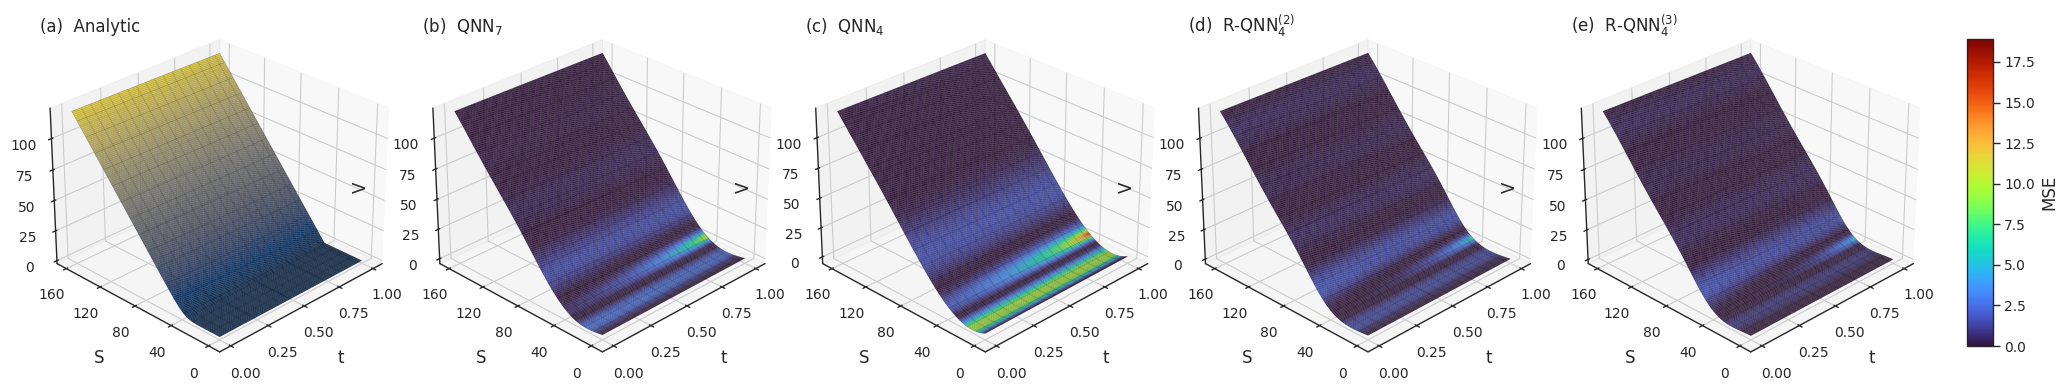

In [19]:
# (2) 3D surfaces: median picks and best picks
#     - (a)-(e) labels, no global title
#     - surface: V(S,t) colored by squared error
#     - analytic: different colormap
#     - add wireframe grid
#     - colorbar label only "MSE"
# ============================================================
def row_to_modeldict(row):
    # plot_df cache might not include full hyperparams; recover from df if needed
    # easiest: search original df by model_path_abs
    mp = row["model_path"]
    # find in df
    hit = df[df["model_path_abs"] == mp]
    if len(hit) == 0:
        # fallback: try basename match
        base = os.path.basename(mp)
        hit = df[df["model_path_abs"].astype(str).str.endswith(base)]
    if len(hit) == 0:
        # last resort: use what exists in row (may break for CQNN)
        return row.to_dict()

    h = hit.iloc[0].to_dict()
    h["model_path"] = mp
    return h

def compute_pick_surfaces(picks_dict):
    V_dict  = {"Analytic": V_true}
    SE_dict = {"Analytic": np.zeros_like(V_true)}
    for label in order_models:
        r = row_to_modeldict(picks_dict[label])
        model = load_model_from_row(r, device=device_eval)
        Vp = predict_on_mesh(model, S_mesh, t_mesh, device=device_eval)
        SE = (Vp - V_true)**2
        V_dict[label]  = Vp
        SE_dict[label] = SE
    return V_dict, SE_dict

def plot_3d_panel(V_dict, SE_dict, ds=SURF_DS, elev=28, azim=-135):
    Emax = max(float(np.max(SE_dict[m])) for m in order_models)
    norm_err = Normalize(vmin=0.0, vmax=Emax if Emax > 0 else 1.0)

    Sds = S_mesh[::ds, ::ds]
    tds = t_mesh[::ds, ::ds]

    cmap_err = cm.turbo
    cmap_ana = cm.cividis

    fig = plt.figure(figsize=(21.0, 4.8))

    letters = ["(a)", "(b)", "(c)", "(d)", "(e)"]
    names   = ["Analytic", "QNN$_7$", "QNN$_4$", r"R-QNN$^{(2)}_4$", r"R-QNN$^{(3)}_4$"]

    for j, col in enumerate(cols_order):
        ax = fig.add_subplot(1, len(cols_order), j+1, projection="3d")

        V = V_dict[col][::ds, ::ds]
        E = SE_dict[col][::ds, ::ds]

        if col == "Analytic":
            vmin, vmax = float(np.min(V)), float(np.max(V))
            normV = Normalize(vmin=vmin, vmax=vmax if vmax>vmin else vmin+1.0)
            facecols = cmap_ana(normV(V))
        else:
            facecols = cmap_err(norm_err(E))

        ax.plot_surface(
            tds, Sds, V,
            rstride=1, cstride=1,
            facecolors=facecols,
            linewidth=0.25, edgecolor=(0,0,0,0.22),
            antialiased=True,
            shade=False
        )
        ax.plot_wireframe(
            tds, Sds, V,
            rstride=10, cstride=10,
            color=(0,0,0,0.15),
            linewidth=0.6
        )

        ax.text2D(
            0.02, 0.94,
            f"{letters[j]}  {names[j]}",
            transform=ax.transAxes,
            fontsize=12
        )

        ax.set_xlabel("t", fontsize=12, labelpad=8)
        ax.set_ylabel("S", fontsize=12, labelpad=8)
        ax.set_zlabel("V", fontsize=12, labelpad=10)
        ax.tick_params(axis="both", labelsize=10)

        ax.xaxis.set_major_locator(MaxNLocator(5))
        ax.yaxis.set_major_locator(MaxNLocator(5))
        ax.zaxis.set_major_locator(MaxNLocator(5))

        ax.view_init(elev=elev, azim=azim)
        ax.zaxis.set_rotate_label(False)
        ax.zaxis.label.set_rotation(90)

    mappable = cm.ScalarMappable(norm=norm_err, cmap=cmap_err)
    mappable.set_array([])

    cax = fig.add_axes([0.93, 0.18, 0.012, 0.64])
    cb = fig.colorbar(mappable, cax=cax)
    cb.ax.tick_params(labelsize=10)
    cb.set_label("MSE", fontsize=12)

    plt.tight_layout(rect=[0.00, 0.00, 0.92, 1.00])
    plt.savefig('paper_reduced/plot/result_comparation.png', dpi=300)
    plt.show()

# median panel
V_med, SE_med = compute_pick_surfaces(picks_median)
plot_3d_panel(V_med, SE_med)


# best panel
#V_best, SE_best = compute_pick_surfaces(picks_best)
#plot_3d_panel(V_best, SE_best)

/tmp/ipykernel_223001/2499787188.py:188: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(w_pad=1.2)


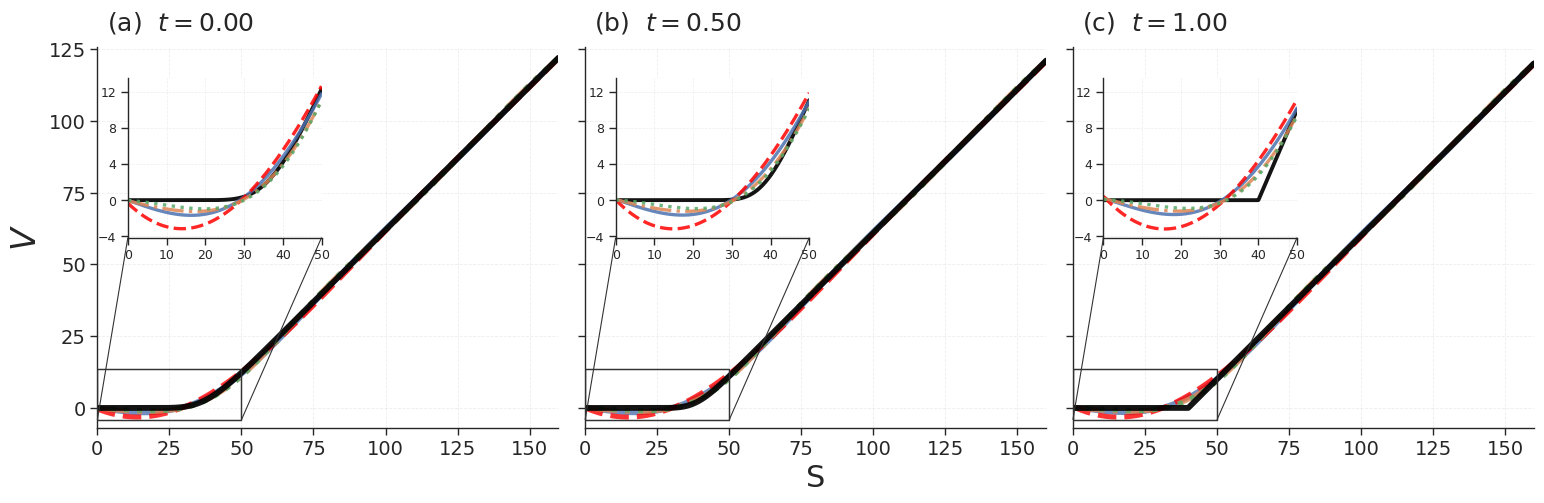

[cache] 2D curves: experimentos_pinn/cache_curves_median_t0_t05_t1.csv


In [28]:
# ============================================================
# (3) 2D curves: t=0,0.5,1 — MEDIAN by loss
#     - cache curve data; if exists, load
# ============================================================

import os
import numpy as np
import pandas as pd
import torch as tc
import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# ------------------------------------------------------------
# Ajuste do zoom: AGORA 0 a 50
# ------------------------------------------------------------
XIN1, XIN2 = 0.0, 50.0

S_line = np.linspace(0.0, S_max, N_LINE).reshape(-1, 1)

# =========================
# Cache (load or compute)
# =========================
if os.path.exists(CACHE_CURVCSV):
    curv = pd.read_csv(CACHE_CURVCSV)
else:
    rows = []
    for t0 in t_list:
        t_line = (t0 * np.ones_like(S_line)).reshape(-1, 1)
        V_ana  = bs.V(S_line, t_line, option_type=option_type).reshape(-1)

        base_df = pd.DataFrame({"t": t0, "S": S_line.reshape(-1), "Analytic": V_ana})

        for label in order_models:
            r = row_to_modeldict(picks_median[label])
            model = load_model_from_row(r, device=device_eval)

            S_n, t_n = norm_in(S_line, t_line)
            X = np.concatenate([S_n, t_n], axis=1).astype(np.float32)
            X_t = tc.from_numpy(X).to(device_eval)

            with tc.no_grad():
                V_pred_norm = model(X_t).detach().cpu().numpy().reshape(-1)
            V_pred = denorm_out(V_pred_norm)

            base_df[label] = V_pred

        rows.append(base_df)

    curv = pd.concat(rows, ignore_index=True)
    curv.to_csv(CACHE_CURVCSV, index=False)

# =========================
# Shared y-limits (main)
# =========================
allV = []
for t0 in t_list:
    d0 = curv[curv["t"] == t0]
    for col in ["Analytic"] + order_models:
        allV.append(d0[col].to_numpy())
allV = np.concatenate(allV)

ymin = float(np.min(allV))
ymax = float(np.max(allV))
pad  = 0.03 * (ymax - ymin + 1e-12)
ymin, ymax = ymin - pad, ymax + pad

# =========================
# Shared inset y-limits for S in [0,50]
# =========================
mask_in = (curv["S"] >= XIN1) & (curv["S"] <= XIN2)
allVin = []
for t0 in t_list:
    d0 = curv[(curv["t"] == t0) & mask_in]
    for col in ["Analytic"] + order_models:
        allVin.append(d0[col].to_numpy())
allVin = np.concatenate(allVin)

yin_min = float(np.min(allVin))
yin_max = float(np.max(allVin))
pad_in  = 0.06 * (yin_max - yin_min + 1e-12)
yin_min, yin_max = yin_min - pad_in, yin_max + pad_in

# =========================
# Plot (3 panels)
# =========================
fig, axes = plt.subplots(1, 3, figsize=(15.6, 5.2), sharey=True)
letters = ["(a)", "(b)", "(c)"]

for j, t0 in enumerate(t_list):
    ax = axes[j]
    d  = curv[curv["t"] == t0].copy()
    S  = d["S"].to_numpy()

    # --- main lines
    ax.plot(S, d["Analytic"].to_numpy(), lw=4.2, color="black", alpha=0.92, zorder=5)
    for label in order_models:
        ax.plot(
            S, d[label].to_numpy(),
            lw=3.6,
            ls=ls_map[label],
            color=color_map[label],
            alpha=0.80,
            zorder=4
        )

    ax.set_xlim(0, 160)
    ax.set_ylim(ymin, ymax)

    ax.xaxis.set_major_locator(MaxNLocator(7))
    ax.yaxis.set_major_locator(MaxNLocator(6))

    if j != 0:
        ax.tick_params(labelleft=False)
    else:
        ax.set_ylabel(r"$V$", fontsize=24)

    if j == 1:
        ax.set_xlabel("S", fontsize=22)

    ax.tick_params(axis="both", labelsize=14)
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.35)
    sns.despine(trim=False, ax=ax)

    ax.text(
    0.02, 1.03,
    rf"{letters[j]}  $t={t0:.2f}$",
    transform=ax.transAxes,
    ha="left", va="bottom",
    fontsize=18,
    clip_on=False   
    )

    # =========================================================
    # RETÂNGULO + INSET + MARK_INSET (corrigidos)
    # =========================================================

    # retângulo mostra exatamente a região do inset
    rect = Rectangle(
        (XIN1, yin_min),
        XIN2 - XIN1,
        yin_max - yin_min,
        fill=False,
        ec="0.20",
        lw=1.0,
        alpha=0.95,
        zorder=6
    )
    ax.add_patch(rect)

    # inset maior e bem posicionado (não corta e não sobrepõe de forma feia)
    ins = inset_axes(ax, width="42%", height="42%", loc="upper left", borderpad=2)
    
    ins.set_zorder(20)
    ins.patch.set_facecolor("white")
    ins.patch.set_alpha(1.0)

    # dados do inset (ESSE painel)
    mask = (S >= XIN1) & (S <= XIN2)
    S_in = S[mask]

    ins.plot(S_in, d["Analytic"].to_numpy()[mask], lw=2.8, color="black", alpha=0.92)
    for label in order_models:
        ins.plot(
            S_in, d[label].to_numpy()[mask],
            lw=2.4,
            ls=ls_map[label],
            color=color_map[label],
            alpha=0.85
        )

    ins.set_xlim(XIN1, XIN2)
    ins.set_ylim(yin_min, yin_max)

    ins.xaxis.set_major_locator(MaxNLocator(6))
    ins.yaxis.set_major_locator(MaxNLocator(5))
    ins.tick_params(axis="both", labelsize=9)
    ins.grid(True, linestyle="--", linewidth=0.5, alpha=0.35)
    sns.despine(trim=False, ax=ins)

    # conecta retângulo ↔ inset sem aquelas diagonais “feias”
    # (loc1/loc2 ajustados para sair mais “reto”)
    mark_inset(ax, ins, loc1=3, loc2=4, fc="none", ec="0.20", lw=0.8)

plt.tight_layout(w_pad=1.2)
plt.savefig('paper_reduced/plot/selected_time.png', dpi=300)
plt.show()

print(f"[cache] 2D curves: {CACHE_CURVCSV}")
